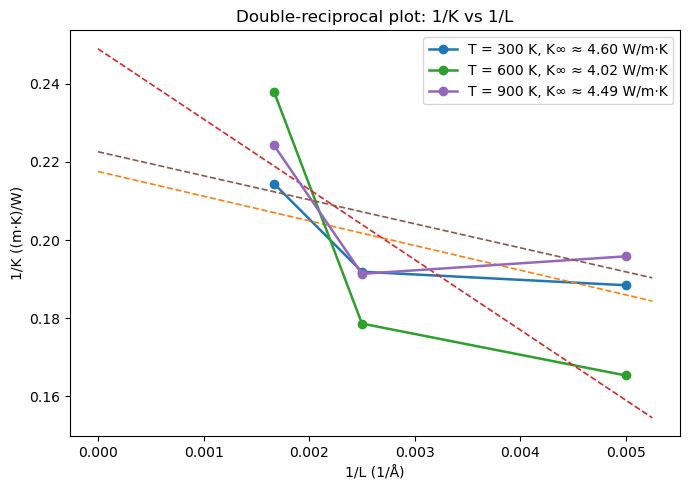

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Read Excel
file_path = "wrapup.xlsx"
sheet_name = "main"
df = pd.read_excel(file_path, sheet_name=sheet_name)

# Use final reported values: 4 ns + K_last4avg
df_final = df[df["Time(ns)"] == 4].copy()

# Add reciprocal columns
df_final["inv_L"] = 1.0 / df_final["Size"]
df_final["inv_K"] = 1.0 / df_final["K_last4avg (W/m·K)"]

plt.figure(figsize=(7,5))

for temp in sorted(df_final["Temp"].unique()):
    sub = df_final[df_final["Temp"] == temp].sort_values("Size")

    x = sub["inv_L"].values
    y = sub["inv_K"].values

    # linear fit
    slope, intercept = np.polyfit(x, y, 1)
    x_fit = np.linspace(0, x.max()*1.05, 100)
    y_fit = slope * x_fit + intercept

    # extrapolated macroscopic conductivity
    if intercept > 0:
        K_inf = 1.0 / intercept
        label = f"T = {temp} K, K∞ ≈ {K_inf:.2f} W/m·K"
    else:
        K_inf = np.nan
        label = f"T = {temp} K"

    plt.plot(x, y, marker="o", linewidth=1.8, label=label)
    plt.plot(x_fit, y_fit, linestyle="--", linewidth=1.2)

plt.xlabel("1/L (1/Å)")
plt.ylabel("1/K ((m·K)/W)")
plt.title("Double-reciprocal plot: 1/K vs 1/L")
plt.legend()
plt.tight_layout()
plt.savefig("invK_vs_invL.png", dpi=300)
plt.show()

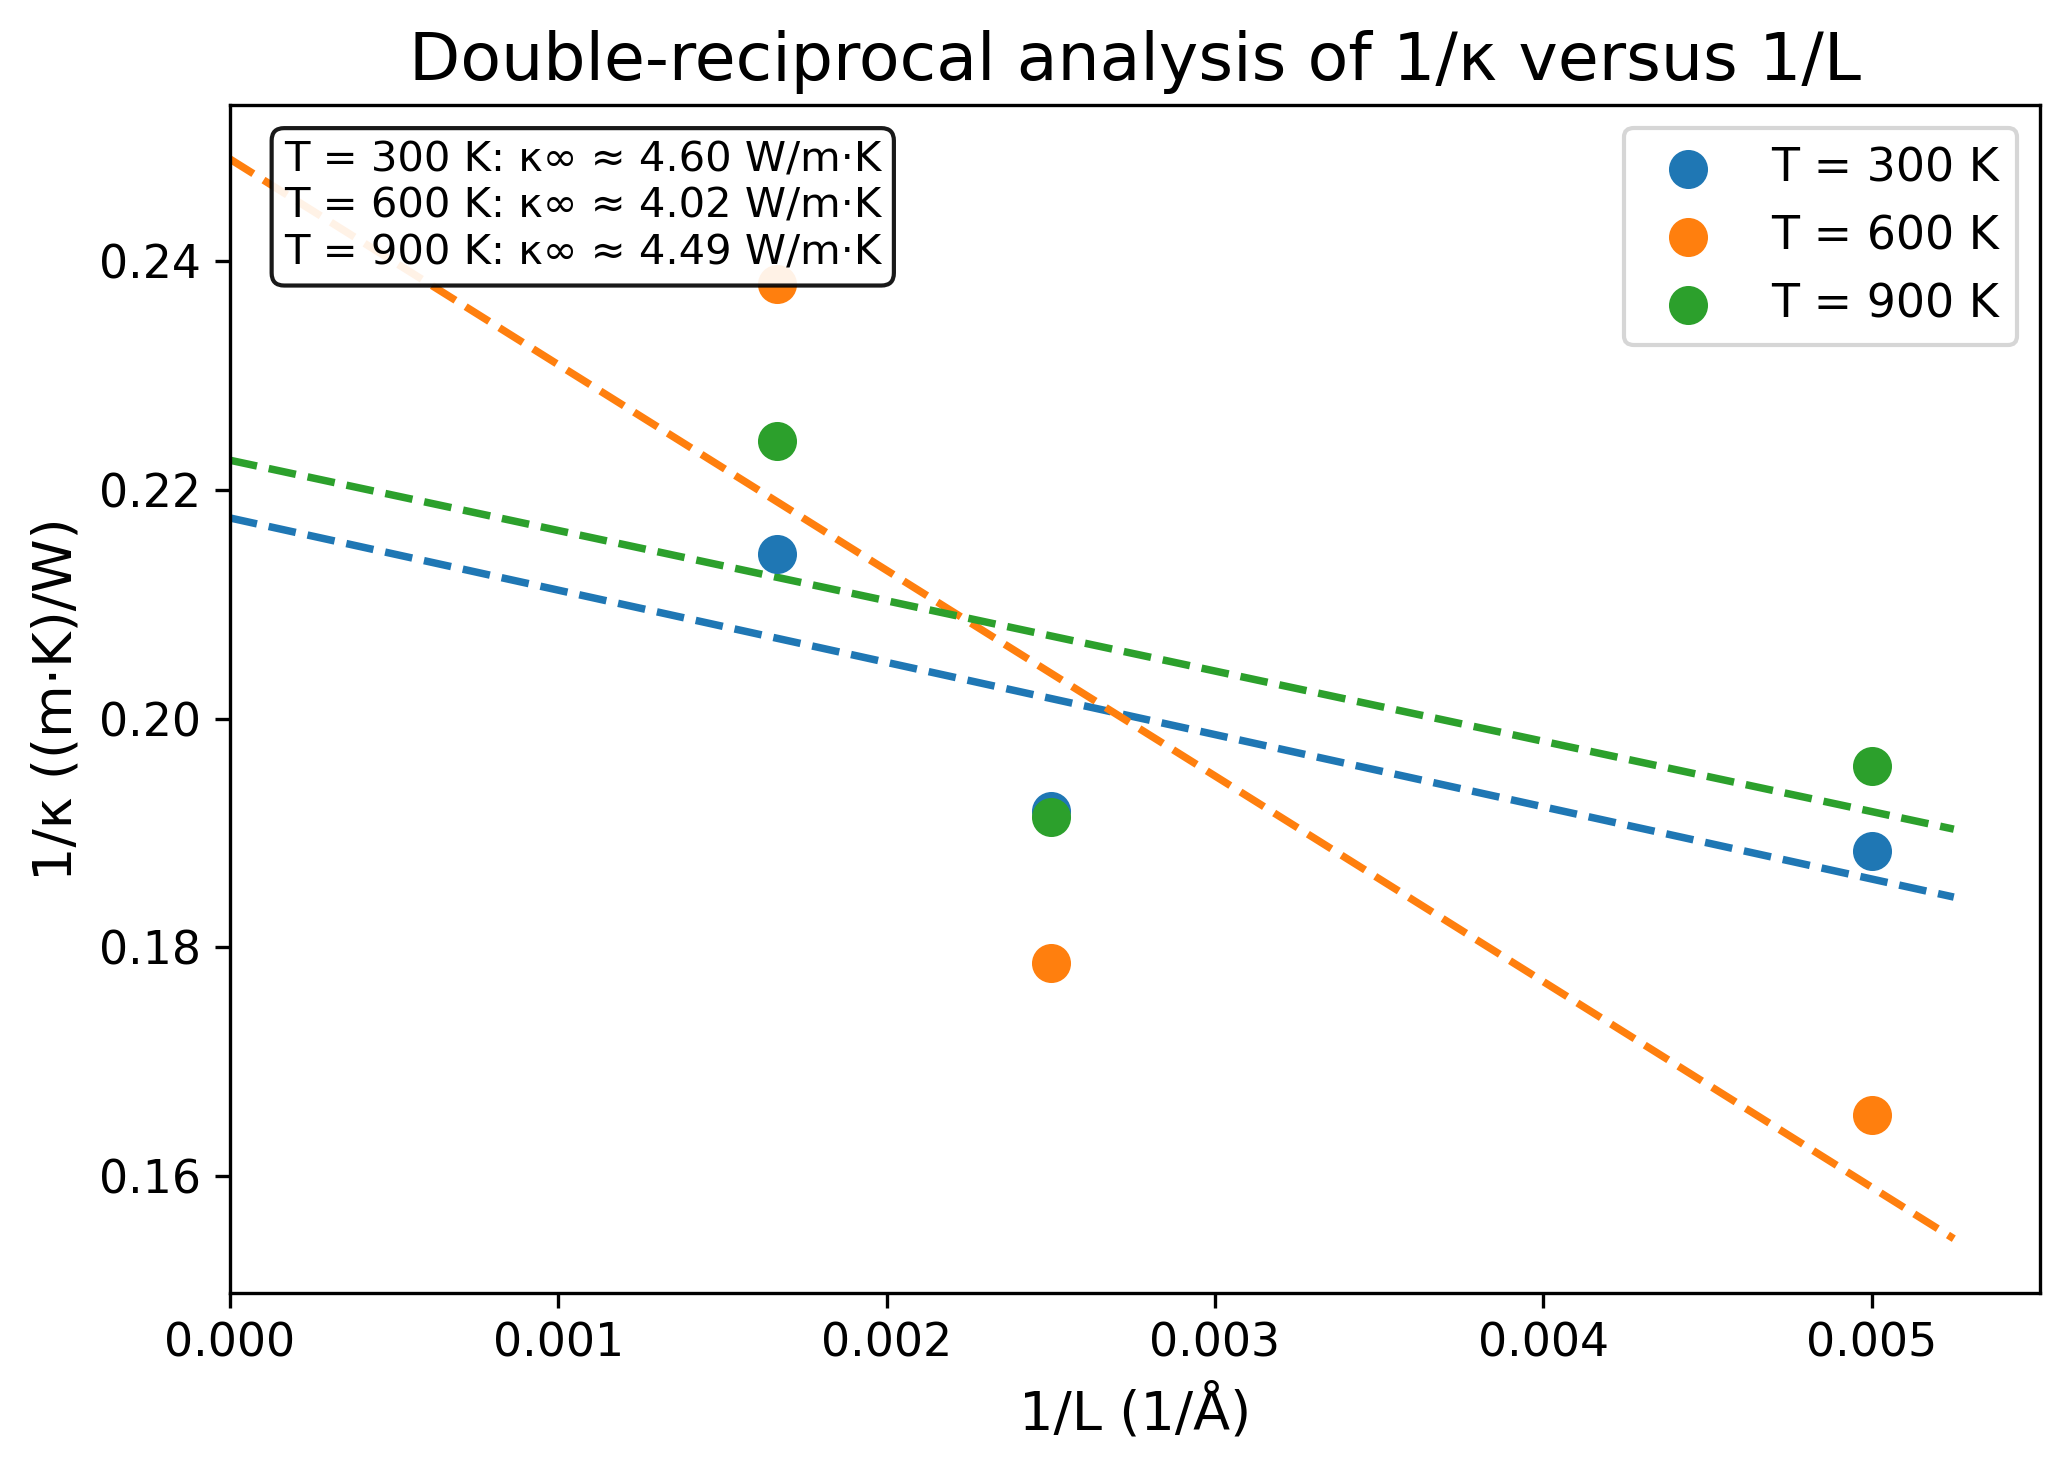

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Read Excel
file_path = "wrapup.xlsx"
sheet_name = "main"
df = pd.read_excel(file_path, sheet_name=sheet_name)

# Use final reported values: 4 ns + K_last4avg
df_final = df[df["Time(ns)"] == 4].copy()

# Add reciprocal columns
df_final["inv_L"] = 1.0 / df_final["Size"]
df_final["inv_kappa"] = 1.0 / df_final["K_last4avg (W/m·K)"]

# Fixed temperature order
temps = sorted(df_final["Temp"].unique())

# Let matplotlib assign default colors consistently
fig, ax = plt.subplots(figsize=(7, 5), dpi=300)

kappa_inf_lines = []

for temp in temps:
    sub = df_final[df_final["Temp"] == temp].sort_values("Size")

    x = sub["inv_L"].values
    y = sub["inv_kappa"].values

    # linear fit
    slope, intercept = np.polyfit(x, y, 1)
    x_fit = np.linspace(0, x.max() * 1.05, 200)
    y_fit = slope * x_fit + intercept

    # scatter points
    scatter = ax.scatter(
        x, y,
        s=70,
        label=f"T = {temp} K",
        zorder=3
    )

    color = scatter.get_facecolor()[0]

    # dashed fit line with same color
    ax.plot(
        x_fit, y_fit,
        linestyle="--",
        linewidth=1.8,
        color=color,
        zorder=2
    )

    # save extrapolated kappa_infinity
    if intercept > 0:
        kappa_inf = 1.0 / intercept
        kappa_inf_lines.append(f"T = {temp} K: κ∞ ≈ {kappa_inf:.2f} W/m·K")
    else:
        kappa_inf_lines.append(f"T = {temp} K: κ∞ not physical")

# Axes labels and title
ax.set_xlabel("1/L (1/Å)", fontsize=13)
ax.set_ylabel("1/κ ((m·K)/W)", fontsize=13)
ax.set_title("Double-reciprocal analysis of 1/κ versus 1/L", fontsize=16)

# Legend only for temperatures
ax.legend(loc="upper right", fontsize=11, frameon=True)

# Text box for extrapolated values
textbox = "\n".join(kappa_inf_lines)
ax.text(
    0.03, 0.97, textbox,
    transform=ax.transAxes,
    fontsize=10,
    va="top",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.9)
)

# Optional: slightly cleaner look
ax.tick_params(axis="both", labelsize=11)
ax.set_xlim(left=0)

plt.tight_layout()
plt.savefig("invK_vs_invL1.png", dpi=300)
plt.show()

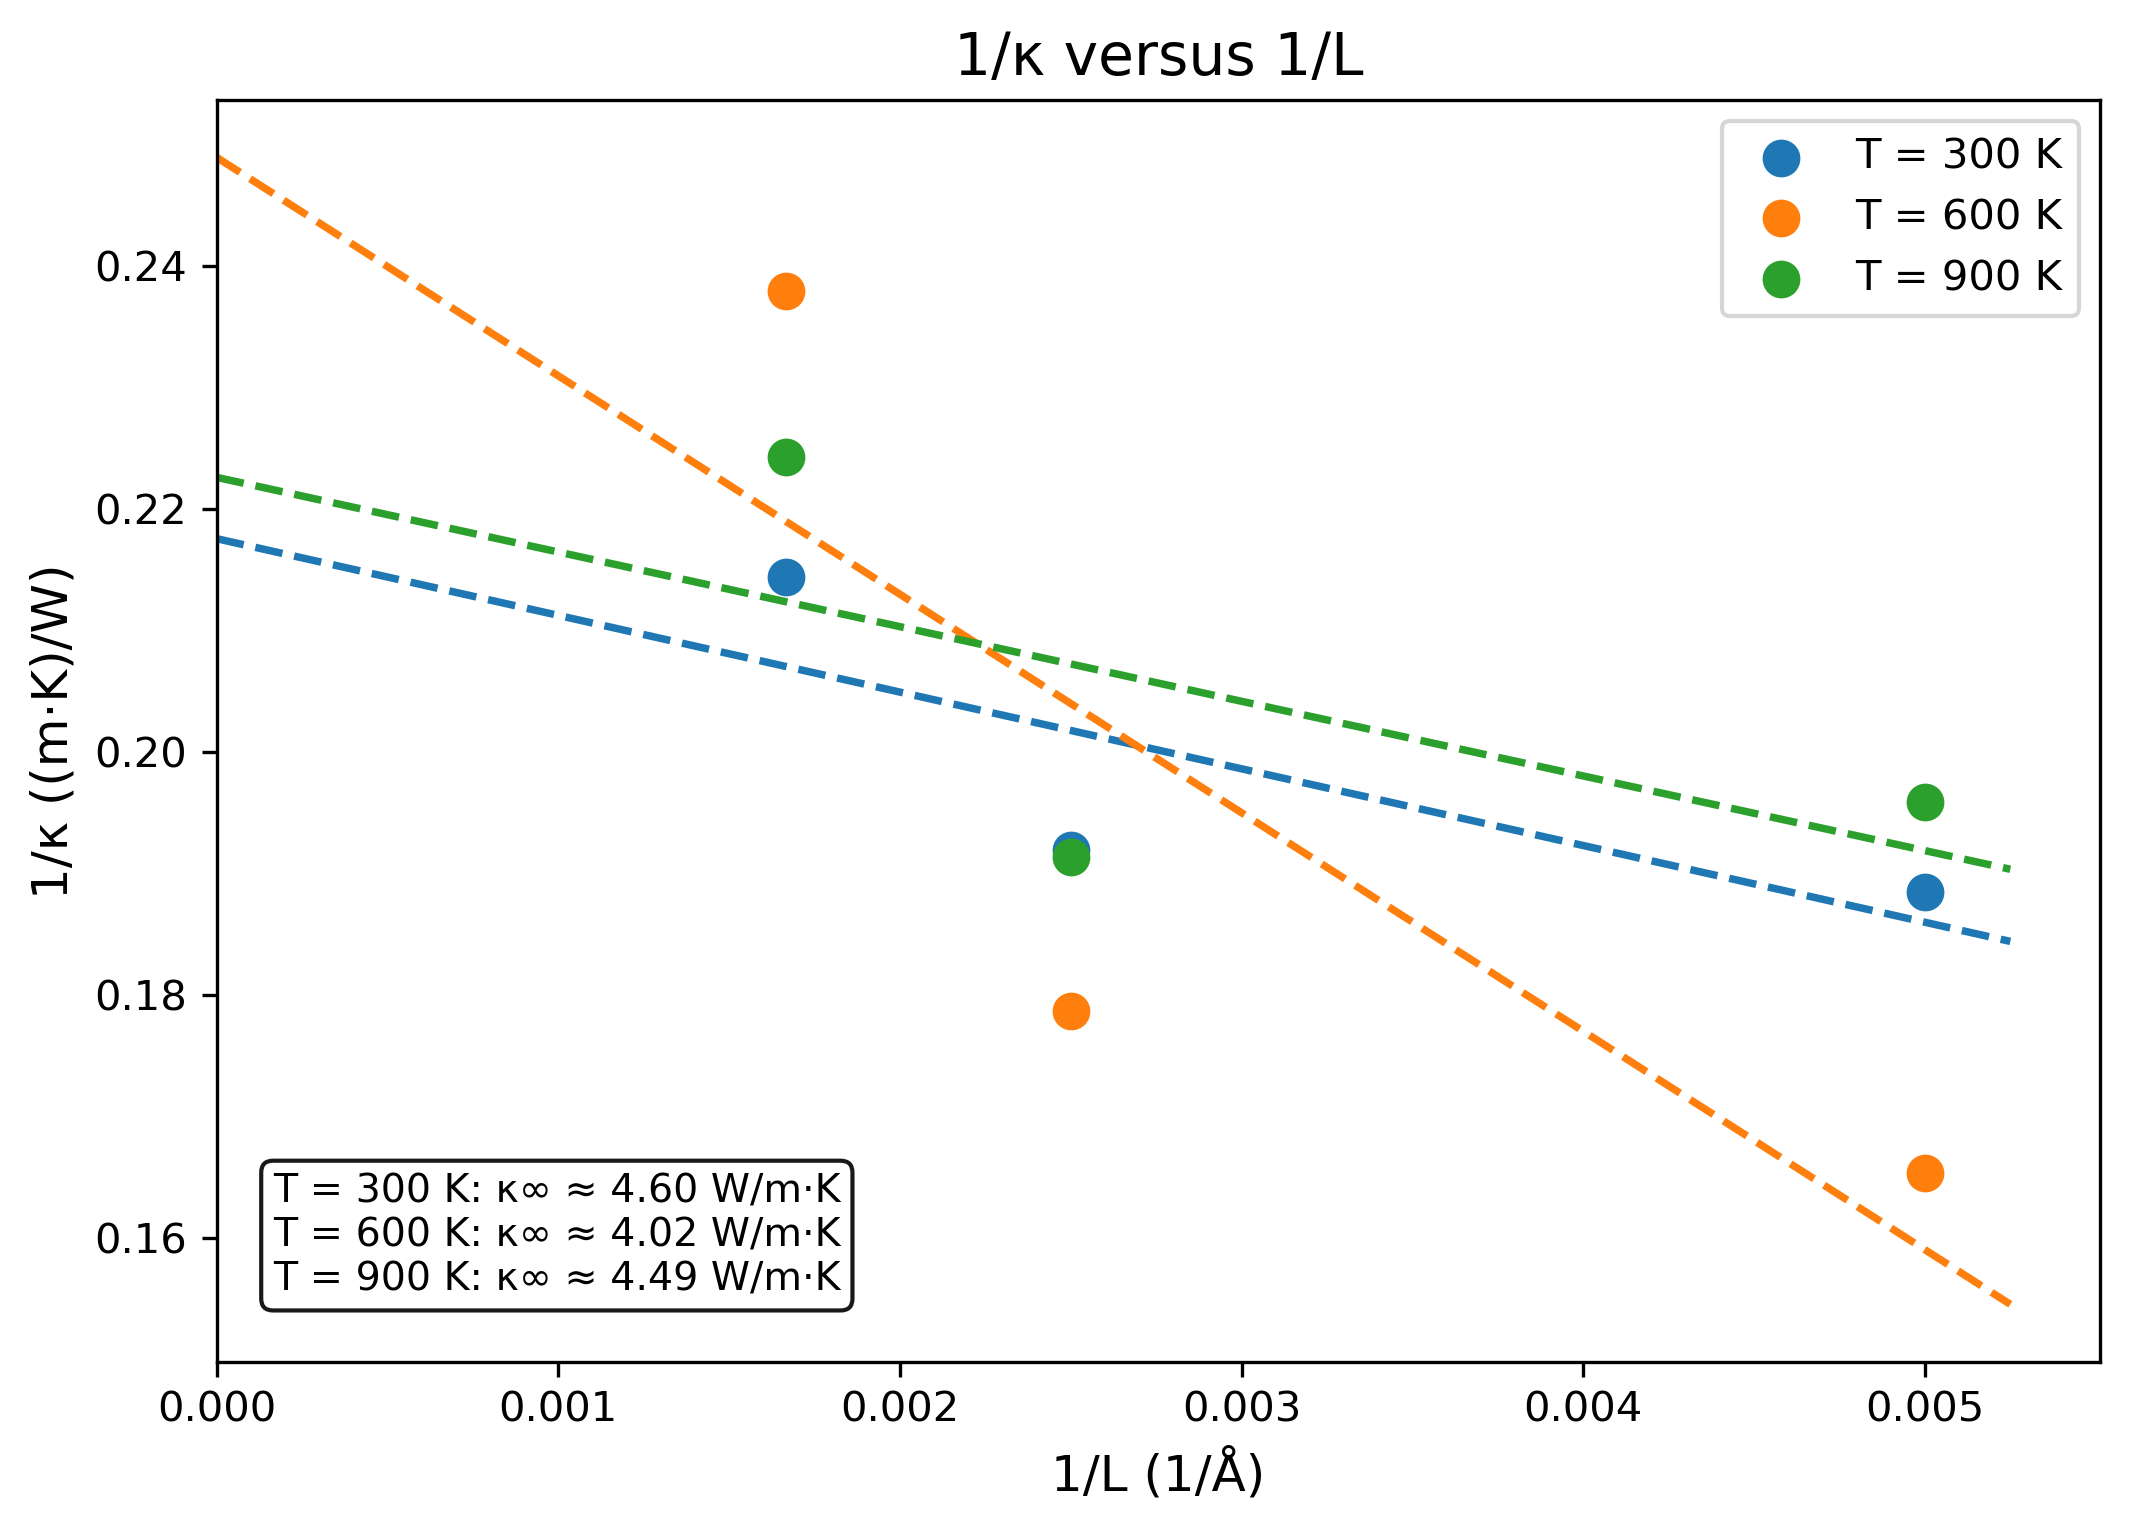

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Read Excel
file_path = "wrapup.xlsx"
sheet_name = "main"
df = pd.read_excel(file_path, sheet_name=sheet_name)

# Use final reported values: 4 ns + K_last4avg
df_final = df[df["Time(ns)"] == 4].copy()

# Add reciprocal columns
df_final["inv_L"] = 1.0 / df_final["Size"]
df_final["inv_kappa"] = 1.0 / df_final["K_last4avg (W/m·K)"]

temps = sorted(df_final["Temp"].unique())

fig, ax = plt.subplots(figsize=(7.2, 5.2), dpi=300)

kappa_inf_lines = []

for temp in temps:
    sub = df_final[df_final["Temp"] == temp].sort_values("Size")

    x = sub["inv_L"].values
    y = sub["inv_kappa"].values

    # Linear fit
    slope, intercept = np.polyfit(x, y, 1)
    x_fit = np.linspace(0, x.max() * 1.05, 200)
    y_fit = slope * x_fit + intercept

    # Scatter points
    scatter = ax.scatter(
        x, y,
        s=65,
        label=f"T = {temp} K",
        zorder=3
    )

    color = scatter.get_facecolor()[0]

    # Dashed fit line with same color
    ax.plot(
        x_fit, y_fit,
        linestyle="--",
        linewidth=1.8,
        color=color,
        zorder=2
    )

    # Save extrapolated kappa infinity
    if intercept > 0:
        kappa_inf = 1.0 / intercept
        kappa_inf_lines.append(f"T = {temp} K: κ∞ ≈ {kappa_inf:.2f} W/m·K")
    else:
        kappa_inf_lines.append(f"T = {temp} K: κ∞ not physical")

# Labels and title
ax.set_xlabel("1/L (1/Å)", fontsize=12)
ax.set_ylabel("1/κ ((m·K)/W)", fontsize=12)
ax.set_title("1/κ versus 1/L", fontsize=14)

# Legend
ax.legend(loc="upper right", fontsize=10, frameon=True)

# Move text box to lower left
textbox = "\n".join(kappa_inf_lines)
ax.text(
    0.03, 0.05, textbox,
    transform=ax.transAxes,
    fontsize=9.5,
    va="bottom",
    ha="left",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.9)
)

# Cleaner axis style
ax.tick_params(axis="both", labelsize=10)
ax.set_xlim(left=0)

plt.tight_layout()
plt.savefig("invK_vs_invL22.png", dpi=300, bbox_inches="tight")
plt.show()